In [35]:
import numpy as np
import networkx as nx
from nsw import NSW, Node, cosine_distance
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


In [39]:
#Create GRAPH

n = 40

vectors = np.random.uniform(-5, 5, (n, 2)).round(2)


nsw = NSW(
    M=3,
    ef_construction=20,
    distance_func=cosine_distance
)


#add nodes
for i, vector in enumerate(vectors):

    node = Node(vector=vector, id=i)
    nsw.insert(node)



In [40]:
def visualize_nsw_xy(nsw: NSW, title="NSW Graph", query=None, query_results=None):
    """
    Plot nodes on the XY plane.
    - Each node is a point at its (x, y) vector coordinates
    - Edges drawn as lines between connected nodes
    - Edge label shows cosine distance
    - Entry point highlighted in orange
    - Optionally highlight a query point and its search results
    
    query_results: list of (distance, node_id) tuples from nsw.search()
    """

    fig, ax = plt.subplots(figsize=(12, 10))
    ax.set_title(title, fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel("X", fontsize=11)
    ax.set_ylabel("Y", fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.axhline(0, color="black", linewidth=0.5, alpha=0.4)
    ax.axvline(0, color="black", linewidth=0.5, alpha=0.4)

    # ── draw edges ────────────────────────────────────────────────────────────
    seen_edges = set()
    for nid, node in nsw.nodes.items():
        for neighbor_id in node.neighbors:
            edge = tuple(sorted((nid, neighbor_id)))
            if edge in seen_edges:
                continue
            seen_edges.add(edge)

            n2 = nsw.nodes[neighbor_id]
            ax.plot([node.vector[0], n2.vector[0]],
                    [node.vector[1], n2.vector[1]],
                    color="#AAAAAA", linewidth=1.2, alpha=0.6, zorder=1)

            # Cosine distance label at edge midpoint
            mid_x = (node.vector[0] + n2.vector[0]) / 2
            mid_y = (node.vector[1] + n2.vector[1]) / 2
            dist = nsw.distance_func(node.vector, n2.vector)
            ax.text(mid_x, mid_y, f"{dist:.3f}",
                    fontsize=7, color="#CC0000", ha="center", va="center",
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7),
                    zorder=3)

    # ── draw nodes ────────────────────────────────────────────────────────────
    # query_results is a list of (dist, node_id) tuples — guard against None
    result_ids = {nid for _, nid in query_results} if query_results else set()

    for nid, node in nsw.nodes.items():
        x, y = node.vector

        if nid == nsw.entry_point:
            color, size = "#FF8C00", 120    # orange — entry point
        elif nid in result_ids:
            color, size = "#2ECC71", 120    # green — search result
        else:
            color, size = "#4A90D9", 100    # blue — regular node

        ax.scatter(x, y, color=color, s=size, zorder=4, edgecolors="white", linewidths=1.5)
        ax.annotate(f"  {nid}: [{x:.2f}, {y:.2f}]",
                    xy=(x, y), fontsize=8, fontweight="bold",
                    color="#222222", zorder=5,
                    xytext=(6, 6), textcoords="offset points")

    # ── draw query point and dashed lines to results ──────────────────────────
    if query is not None:
        ax.scatter(query[0], query[1], color="#E74C3C", s=200, zorder=6,
                   marker="*", edgecolors="white", linewidths=1)
        ax.annotate(f"  query: [{query[0]:.2f}, {query[1]:.2f}]",
                    xy=(query[0], query[1]), fontsize=8, fontweight="bold",
                    color="#E74C3C", zorder=7,
                    xytext=(6, 6), textcoords="offset points")

        # Dashed lines from query to each result node
        if query_results:
            for dist, nid in query_results:
                n = nsw.nodes[nid]
                ax.plot([query[0], n.vector[0]], [query[1], n.vector[1]],
                        color="#2ECC71", linewidth=1.5, linestyle="--", alpha=0.7, zorder=2)

    # ── legend ────────────────────────────────────────────────────────────────
    legend_items = [
        mpatches.Patch(color="#FF8C00", label="Entry point"),
        mpatches.Patch(color="#4A90D9", label="Node"),
    ]
    if query is not None:
        legend_items.append(mpatches.Patch(color="#E74C3C", label="Query ★"))
    if query_results:
        legend_items.append(mpatches.Patch(color="#2ECC71", label="Search results"))

    ax.legend(handles=legend_items, loc="upper left", fontsize=9)

    plt.tight_layout()
    #plt.savefig("nsw_xy.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

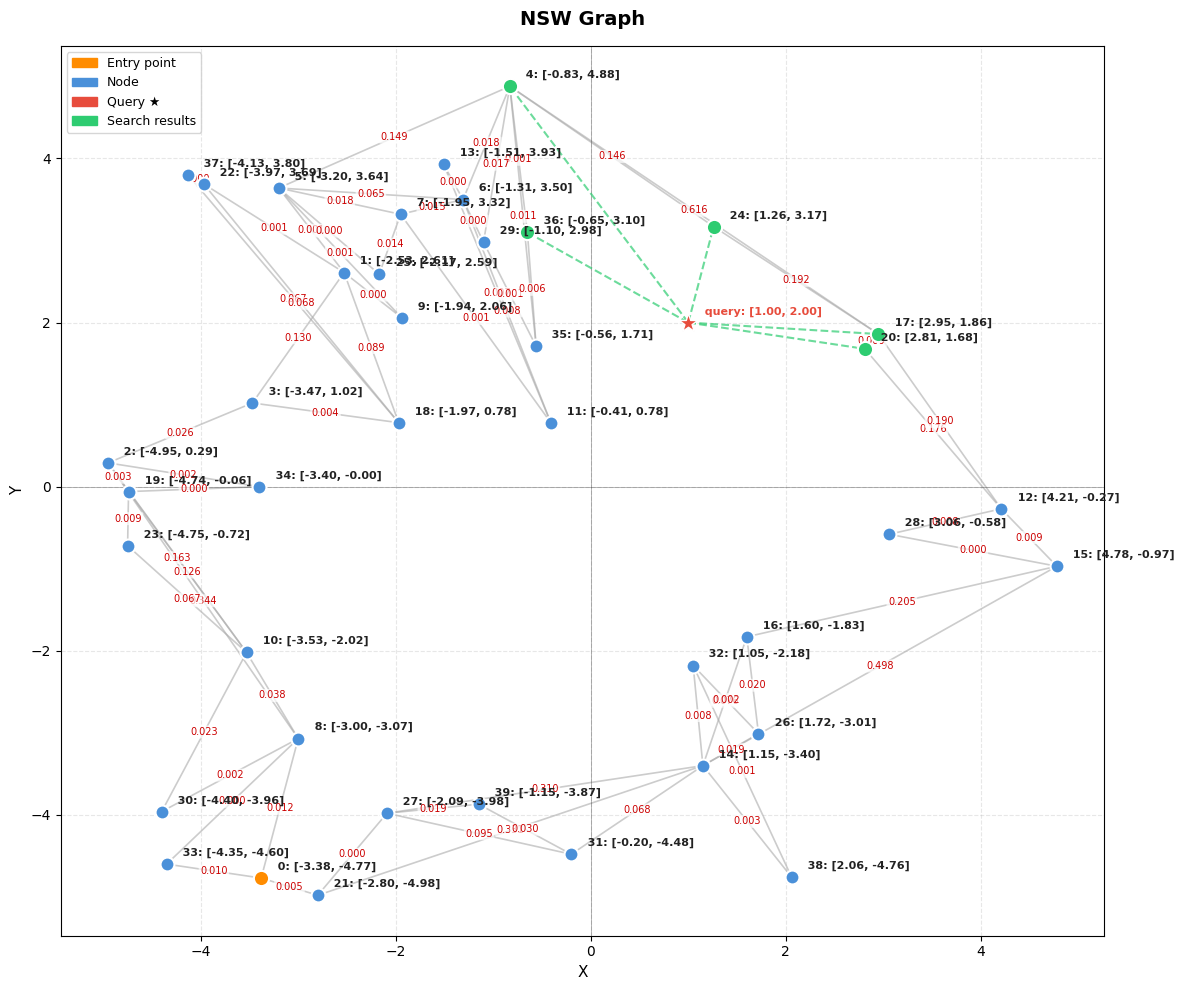

In [41]:
query_vec = np.array([1, 2])

query_results = nsw.search(query_vec, k=5, ef=100)
visualize_nsw_xy(nsw=nsw, query=query_vec, query_results=query_results)

